## 误差作图及显著性分析

In [1]:
import sys
sys.path.append("../")
from predictor_base import predict
from tools import getPairInfo, metric
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np
import torch
import os
import re

In [2]:
# 预测
real, pre = predict(
       "ENSEMBLE",
        "../../IterTransferLearning/KKMModel/confirm-MACCS#openKKmInfer#openLog10-KKM-train-1/model/pre-train-trainR2:0.9212-devR2=0.8002-RMSE=0.8102-MAE=0.5650-epoch=40",
        torch.load("../Data/KKMTestPairInfo")+torch.load("../Data/KKMTrainPairInfo"),
        "../../KKM/Data/NewestFeature/esm1v_t33_650M_UR90S_1_embeding_1280/",
        "../../KKM/Data/NewestFeature/index_smiles",
        True,
        torch.device("cuda:1"),
        "MACCSKeys"
)

log10:True molType:MACCSKeys
complex
complex


100%|███████████████████████████████████████████████████████████| 200/200 [00:41<00:00,  4.78it/s]


In [3]:
from matplotlib import rc
import matplotlib.patches as patches
def err(pre, tar):
    pre = np.array(pre)
    tar = np.array(tar)
    e = pre - tar
    return e

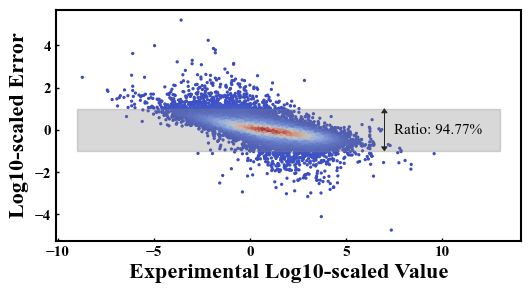

In [4]:
def draw(x, y):
    x = np.array(x)
    y = np.array(y)
    
    plt.figure(figsize=(6, 3))
#     plt.rc('lines', linewidth=10)
    rc('font',**{'family':'Times New Roman','weight':'bold'})
    plt.rcParams['pdf.fonttype'] = 42
    plt.tick_params(direction='in')
    plt.tick_params(which='major',length=2)
    plt.tick_params(which='major',width=1)
    
    xyVstack = np.vstack([x, y])
    kde = gaussian_kde(xyVstack)(xyVstack)
    plt.scatter(x, y, c = kde, cmap="coolwarm", s=1.8)
    rect = patches.Rectangle((-9, -1), 22, 2, alpha=0.3, color='gray', zorder=2)
    
    # 获取当前的坐标轴对象
    ax = plt.gca()
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['top'].set_linewidth(1.5)
    ax.spines['right'].set_linewidth(1.5)

    # 添加矩形到图中
    ax.add_patch(rect)
    
    plt.rcParams['font.family'] = 'Times New Roman'
    plt.xlabel('Experimental Log10-scaled Value', fontsize=16, weight="bold")
    plt.ylabel('Log10-scaled Error', fontsize=16,weight="bold")
    plt.xticks(fontsize=11, weight="bold")
    plt.yticks(fontsize=11, weight="bold")
    
    plt.arrow(7, -0.8, 0, 1.6, head_width=0.3, head_length=0.2, fc='black', ec='black',linewidth=0.5)
    plt.arrow(7, 0.8, 0, -1.6, head_width=0.3, head_length=0.2, fc='black', ec='black',linewidth=0.5)
    plt.text(7.5, -0.2, f'Ratio: {len(y[(y<=1)&(y>=-1)]) / len(y):.2%}', fontweight ="normal", fontsize=11)

    plt.savefig(f"../Fig/Fig7-MACCSKeys-KKM-Errdistribution.png", dpi=600, bbox_inches='tight')
    plt.show()
#     print(f'拟合直线的系数:{r}')
draw(real, err(pre, real))

## 做对比箱型图，并作参数检验

In [1]:
import sys
sys.path.append("../")
from predictor_base import predict
from tools import getPairInfo, metric
import torch
# 预测
baseReal, basePre = predict(
       "KKM",
        "../../KKM/TrainInfo/models/initialTrain-MACCSKeys/ECFPKKmPredictor-trainR2:0.8893-devR2=0.6136-RMSE=1.1116-MAE=0.7944-epoch=100",
        torch.load("../Data/KKMTestPairInfo"),
        "../../KKM/Data/NewestFeature/esm1v_t33_650M_UR90S_1_embeding_1280/",
        "../../KKM/Data/NewestFeature/index_smiles",
        False,
        torch.device("cuda:1"),
        "MACCSKeys"
)
# 预测
real, pre = predict(
       "ENSEMBLE",
        "../../IterTransferLearning/KKMModel/confirm-MACCS#openKKmInfer#openLog10-KKM-train-1/model/pre-train-trainR2:0.9212-devR2=0.8002-RMSE=0.8102-MAE=0.5650-epoch=40",
        torch.load("../Data/KKMTestPairInfo"),
        "../../KKM/Data/NewestFeature/esm1v_t33_650M_UR90S_1_embeding_1280/",
        "../../KKM/Data/NewestFeature/index_smiles",
        True,
        torch.device("cuda:1"),
        "MACCSKeys"
)

log10:False molType:MACCSKeys


100%|█████████████████████████████████████████████████████████████| 20/20 [00:04<00:00,  4.37it/s]


log10:True molType:MACCSKeys
complex
complex


100%|█████████████████████████████████████████████████████████████| 20/20 [00:05<00:00,  3.89it/s]


In [2]:
import numpy as np
from scipy.stats import wilcoxon
baseReal = np.log10(np.power(2, np.array(baseReal)))
basePre = np.log10(np.power(2, np.array(basePre)))

In [4]:
_, p_value = wilcoxon(np.abs(err(pre, real)), np.abs(basePre-baseReal))
print(p_value)

2.6484749437263947e-92


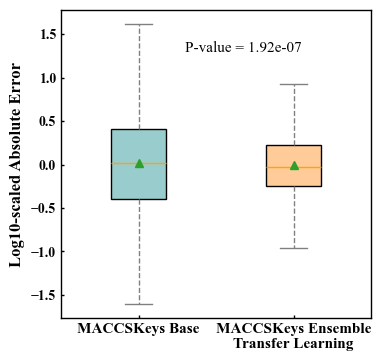

In [26]:
# 做箱型图
plt.figure(figsize=(4, 4))
rc('font',**{'family':'Times New Roman','weight':'bold'})
# plt.rc('lines', linewidth=10)
plt.rcParams['pdf.fonttype'] = 42
plt.tick_params(direction='in')
plt.tick_params(which='major',length=2)
plt.tick_params(which='major',width=1)

labels = ['MACCSKeys Base', 'MACCSKeys Ensemble\nTransfer Learning']
boxplot = plt.boxplot(
            [kkmPre-kkmReal, err(pre, real)], 
            labels=labels, 
            showfliers=False,
            showmeans=True,
            patch_artist=True,
            medianprops={'color': 'orange'},
            whiskerprops={'linestyle': '--', 'color': 'gray'},
            capprops={'color': 'gray'},
            widths=0.35
#             flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 5}
           )
colors = ['#99CCCC', '#FFCC99']
for box, color in zip(boxplot['boxes'], colors):
    box.set_facecolor(color)
    
plt.xticks(fontsize=11)
ax = plt.gca()
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.spines['top'].set_linewidth(1)
ax.spines['right'].set_linewidth(1)
plt.text(1.3, 1.3, f'P-value = {p_value:.3}', fontweight ="normal", fontsize=11)

plt.ylabel("Log10-scaled Error", fontdict={'weight': 'bold', 'fontname': 'Times New Roman', 'size': 12})
plt.savefig(f"../Fig/Fig7-MACCSKeys-KKM-contrast.png", dpi=600, bbox_inches='tight')
plt.show()

In [5]:
import pandas as pd
df = pd.DataFrame({'Baseline':np.abs(basePre-baseReal), 'trans':np.abs(err(pre, real))})
df.to_csv("./fig7data.csv")